Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 15.0 MB/s  0:00:00

   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ------ --------------------------------- 1/6 [multitasking]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ----

[*********************100%***********************]  1 of 1 completed
C:\Users\Riddhi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0064
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 3.4961e-04
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 3.1558e-04
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 3.1897e-04
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 3.1147e-04
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 2.6948e-04
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 2.6707e-04
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 2.5282e-04
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 2.7153e-04
Epoch 10/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 2.2301e-04
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


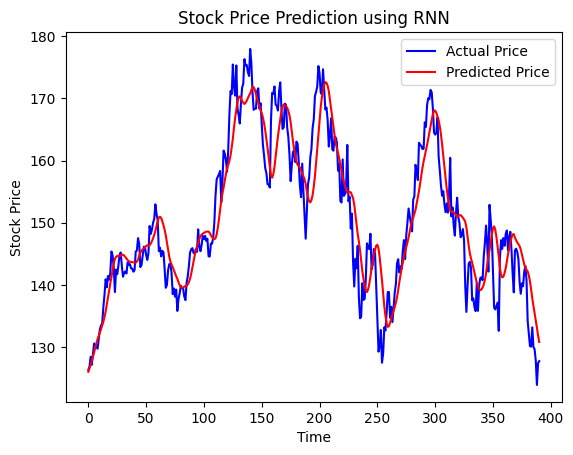

MSE: 26.20011060420157
RMSE: 5.118604360975906


In [2]:
%pip install yfinance


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


import yfinance as yf

data = yf.download('AAPL', start='2015-01-01', end='2023-01-01')

df = data[['Close']]

df.head()


scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)


X = []
y = []

time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)


X = X.reshape(X.shape[0], X.shape[1], 1)


train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))


model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)


predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))


plt.plot(y_test_actual, color='blue', label='Actual Price')
plt.plot(predictions, color='red', label='Predicted Price')

plt.title("Stock Price Prediction using RNN")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)